In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
from datetime import datetime, timedelta
import pytz
import joblib
import os

***Data Collection***

In [2]:
API_KEY = '70ff9507484aa74214bb3005bc88a1bd'
BASE_URL = 'https://api.openweathermap.org/data/2.5/'

In [3]:
data = pd.read_csv('weather.csv')
print(data.shape)
data.head()

(3099, 10)


,Date,Temp,MaxTemp,MinTemp,WindDir,WindSpeed,Humidity,Pressure,Rainfall,RainToday
0,1/1/2015,12.35,21.2,3.5,178.125000,1.925000,90.20,870.446667,0.0,No
1,1/2/2015,12.60,16.0,9.2,150.416667,2.279167,82.40,868.377083,1.6,Yes
2,1/3/2015,13.75,19.0,8.5,148.541667,2.529167,85.05,865.867625,0.0,No
3,1/4/2015,13.75,17.5,10.0,170.041667,2.025000,73.25,865.626500,1.0,Yes
4,1/5/2015,13.15,20.5,5.8,175.541667,1.391667,67.45,865.650750,0.0,No


In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3099 entries, 0 to 3098
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3099 non-null   object 
 1   Temp       3099 non-null   float64
 2   MaxTemp    3099 non-null   float64
 3   MinTemp    3099 non-null   float64
 4   WindDir    3099 non-null   float64
 5   WindSpeed  3099 non-null   float64
 6   Humidity   3099 non-null   float64
 7   Pressure   3099 non-null   float64
 8   Rainfall   3099 non-null   float64
 9   RainToday  3099 non-null   object 
dtypes: float64(8), object(2)
memory usage: 242.2+ KB


,Temp,MaxTemp,MinTemp,WindDir,WindSpeed,Humidity,Pressure,Rainfall
count,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000,3099.000000
mean,19.485560,25.782188,13.188932,155.643198,1.782812,75.151994,864.504221,4.192946
std,5.108793,4.532159,6.156036,31.088675,0.450376,11.642132,3.505459,10.800457
min,7.400000,8.100000,0.000000,0.000000,0.950000,32.100000,855.613353,0.000000
25%,15.050000,22.300000,7.800000,136.375000,1.429167,68.441250,861.846833,0.000000
50%,20.600000,27.000000,13.600000,151.791667,1.716667,77.700000,864.760042,0.000000
75%,24.150000,29.500000,19.400000,173.375000,2.087500,83.216250,867.050208,2.500000
max,27.650000,35.000000,23.500000,251.916667,3.445833,117.300000,872.679583,121.500000


In [5]:
print(data.isnull().sum())
print(f"Number of rows : {len(data)}")
print(f"Number of duplicates : {data.duplicated().sum()}")

Date         0
Temp         0
MaxTemp      0
MinTemp      0
WindDir      0
WindSpeed    0
Humidity     0
Pressure     0
Rainfall     0
RainToday    0
dtype: int64
Number of rows : 3099
Number of duplicates : 0


***Data Cleaning and Preprocessing***

In [6]:
def preprocess_data(filepath='weather.csv'):
    df = pd.read_csv(filepath)
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    df.set_index('Date', inplace=True)
    df.dropna(axis=1, inplace=True)
    if df['RainToday'].dtype == 'object':
        df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
    df['RainToday'] = df['RainToday'].fillna(0)
    df['RainToday'] = df['RainToday'].astype(int)
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    df.dropna(inplace=True)
    return df

In [7]:
def outlier_check(df):
    df_no_outliers = df.copy()
    outlier_check_cols = ['Temp', 'MinTemp', 'MaxTemp', 'WindSpeed','WindDir', 'Humidity','Pressure']
    missing_cols = [col for col in outlier_check_cols if col not in df_no_outliers.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in DataFrame: {missing_cols}")
  
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_no_outliers[outlier_check_cols])
    plt.title('Boxplots BEFORE Outlier Removal')
    plt.xticks(rotation=30)
    plt.show()
    print(f"Original number of rows: {len(df_no_outliers)}")
    initial_rows = len(df_no_outliers)
    for col in outlier_check_cols:
        Q1 = df_no_outliers[col].quantile(0.25)
        Q3 = df_no_outliers[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.0 * IQR
        upper_bound = Q3 + 1.0 * IQR
        df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]
    print(f"Number of rows AFTER removing outliers: {len(df_no_outliers)}")
    print(f"Rows removed: {initial_rows - len(df_no_outliers)}")

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_no_outliers[outlier_check_cols])
    plt.title('Boxplots AFTER Outlier Removal')
    plt.xticks(rotation=30)
    plt.show()
    return df_no_outliers

In [8]:
def features(df):
    featured_df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(featured_df.index):
         featured_df.index = pd.to_datetime(featured_df.index)

    if 'RainToday' in featured_df.columns and featured_df['RainToday'].dtype == 'object':
        featured_df['RainToday'] = featured_df['RainToday'].map({'Yes': 1, 'No': 0})

    featured_df['day_of_year'] = featured_df.index.dayofyear
    featured_df['month'] = featured_df.index.month
    featured_df['day_of_week'] = featured_df.index.dayofweek

    featured_df.dropna(inplace=True)
    return featured_df

Starting Data Processing Pipeline

Preprocessed Data Inspection
Shape: (3099, 9)
Head:
              Temp  MaxTemp  MinTemp     WindDir  WindSpeed  Humidity  \
Date                                                                   
2015-01-01  12.35     21.2      3.5  178.125000   1.925000     90.20   
2015-01-02  12.60     16.0      9.2  150.416667   2.279167     82.40   
2015-01-03  13.75     19.0      8.5  148.541667   2.529167     85.05   
2015-01-04  13.75     17.5     10.0  170.041667   2.025000     73.25   
2015-01-05  13.15     20.5      5.8  175.541667   1.391667     67.45   

              Pressure  Rainfall  RainToday  
Date                                         
2015-01-01  870.446667       0.0          0  
2015-01-02  868.377083       1.6          1  
2015-01-03  865.867625       0.0          0  
2015-01-04  865.626500       1.0          1  
2015-01-05  865.650750       0.0          0  
Missing Values:
 Temp         0
MaxTemp      0
MinTemp      0
WindDir      0
WindSpee

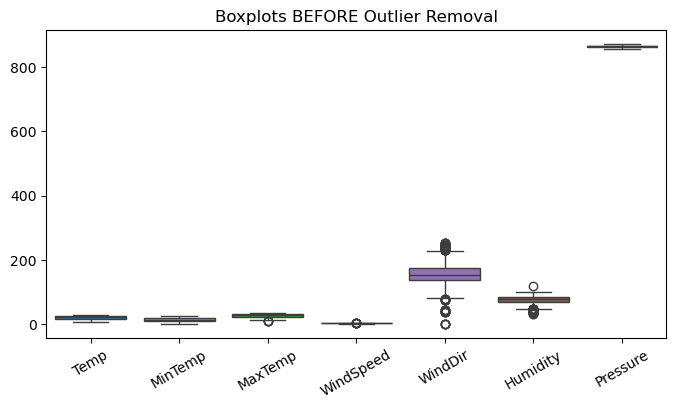

Original number of rows: 3099
Number of rows AFTER removing outliers: 2565
Rows removed: 534


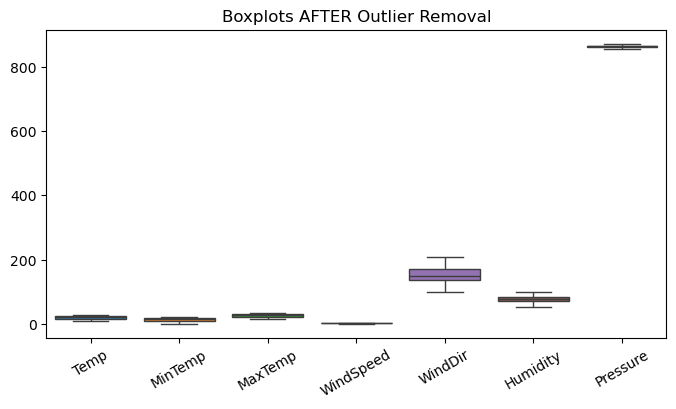


Outlier-Free Data Inspection
Shape: (2565, 9)
Head:
              Temp  MaxTemp  MinTemp     WindDir  WindSpeed  Humidity  \
Date                                                                   
2015-01-01  12.35     21.2      3.5  178.125000   1.925000     90.20   
2015-01-02  12.60     16.0      9.2  150.416667   2.279167     82.40   
2015-01-03  13.75     19.0      8.5  148.541667   2.529167     85.05   
2015-01-04  13.75     17.5     10.0  170.041667   2.025000     73.25   
2015-01-05  13.15     20.5      5.8  175.541667   1.391667     67.45   

              Pressure  Rainfall  RainToday  
Date                                         
2015-01-01  870.446667       0.0          0  
2015-01-02  868.377083       1.6          1  
2015-01-03  865.867625       0.0          0  
2015-01-04  865.626500       1.0          1  
2015-01-05  865.650750       0.0          0  
Missing Values:
 Temp         0
MaxTemp      0
MinTemp      0
WindDir      0
WindSpeed    0
Humidity     0
Pressure    

In [9]:
print("Starting Data Processing Pipeline")
preprocessed_df = preprocess_data(filepath='weather.csv')
print("\nPreprocessed Data Inspection")
print("Shape:", preprocessed_df.shape)
print("Head:\n", preprocessed_df.head())
print("Missing Values:\n", preprocessed_df.isnull().sum())

df_no_outliers = outlier_check(preprocessed_df)
print("\nOutlier-Free Data Inspection")
print("Shape:", df_no_outliers.shape)
print("Head:\n", df_no_outliers.head())
print("Missing Values:\n", df_no_outliers.isnull().sum())

print(" Applying Simplified Features")
featured_df = features(df_no_outliers)
FEATURES = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindDir', 'Pressure',
    'WindSpeed', 'Temp', 'Humidity', 
    'day_of_year', 'month', 'day_of_week'
]
TARGET_RAIN = 'RainToday'
TARGET_TEMP = 'Temp'
TARGET_HUMIDITY = 'Humidity'

print(f"New features for modeling: {FEATURES}")
print(f"\nFinal DataFrame (with new features): \n{featured_df.head()}")

featured_df = features(df_no_outliers)
print("\nFeature-Engineered Data Inspection")
print("Shape:", featured_df.shape)
print("Head:\n", featured_df.head())
print("Missing Values:\n", featured_df.isnull().sum())

print("\nData processing pipeline completed successfully.")

**Data Visualization**


Distribution of the 'RainToday' target variable:
RainToday
0    0.581287
1    0.418713
Name: proportion, dtype: float64


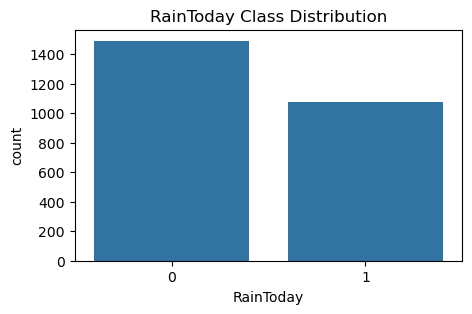

In [10]:
print(f"\nDistribution of the '{TARGET_RAIN}' target variable:")
print(featured_df[TARGET_RAIN].value_counts(normalize=True))
plt.figure(figsize=(5, 3))
sns.countplot(x=TARGET_RAIN, data=featured_df)
plt.title('RainToday Class Distribution')
plt.show()


Plotting Feature Correlation Heatmap


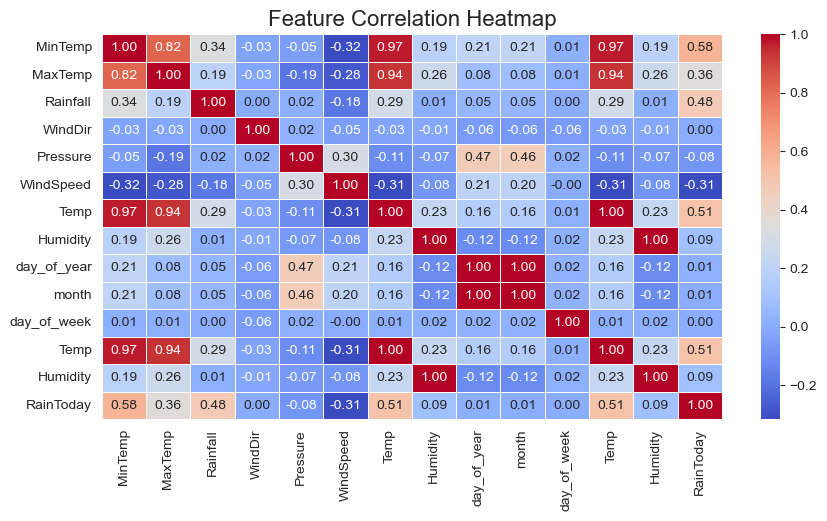

In [11]:
sns.set_style('whitegrid')
# Visualize Feature Correlation with a Heatmap
print("\nPlotting Feature Correlation Heatmap")
plt.figure(figsize=(10, 5))
correlation_matrix = featured_df[FEATURES + [TARGET_TEMP, TARGET_HUMIDITY, TARGET_RAIN]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

Plotting Temperature over time


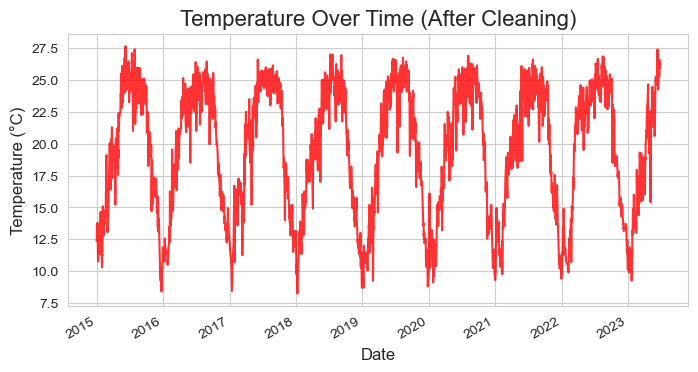

In [12]:
sns.set_style('whitegrid')
print("Plotting Temperature over time")
plt.figure(figsize=(8, 4))
featured_df[TARGET_TEMP].plot(color='red', alpha=0.8)
plt.title('Temperature Over Time (After Cleaning)', fontsize=16)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.show()

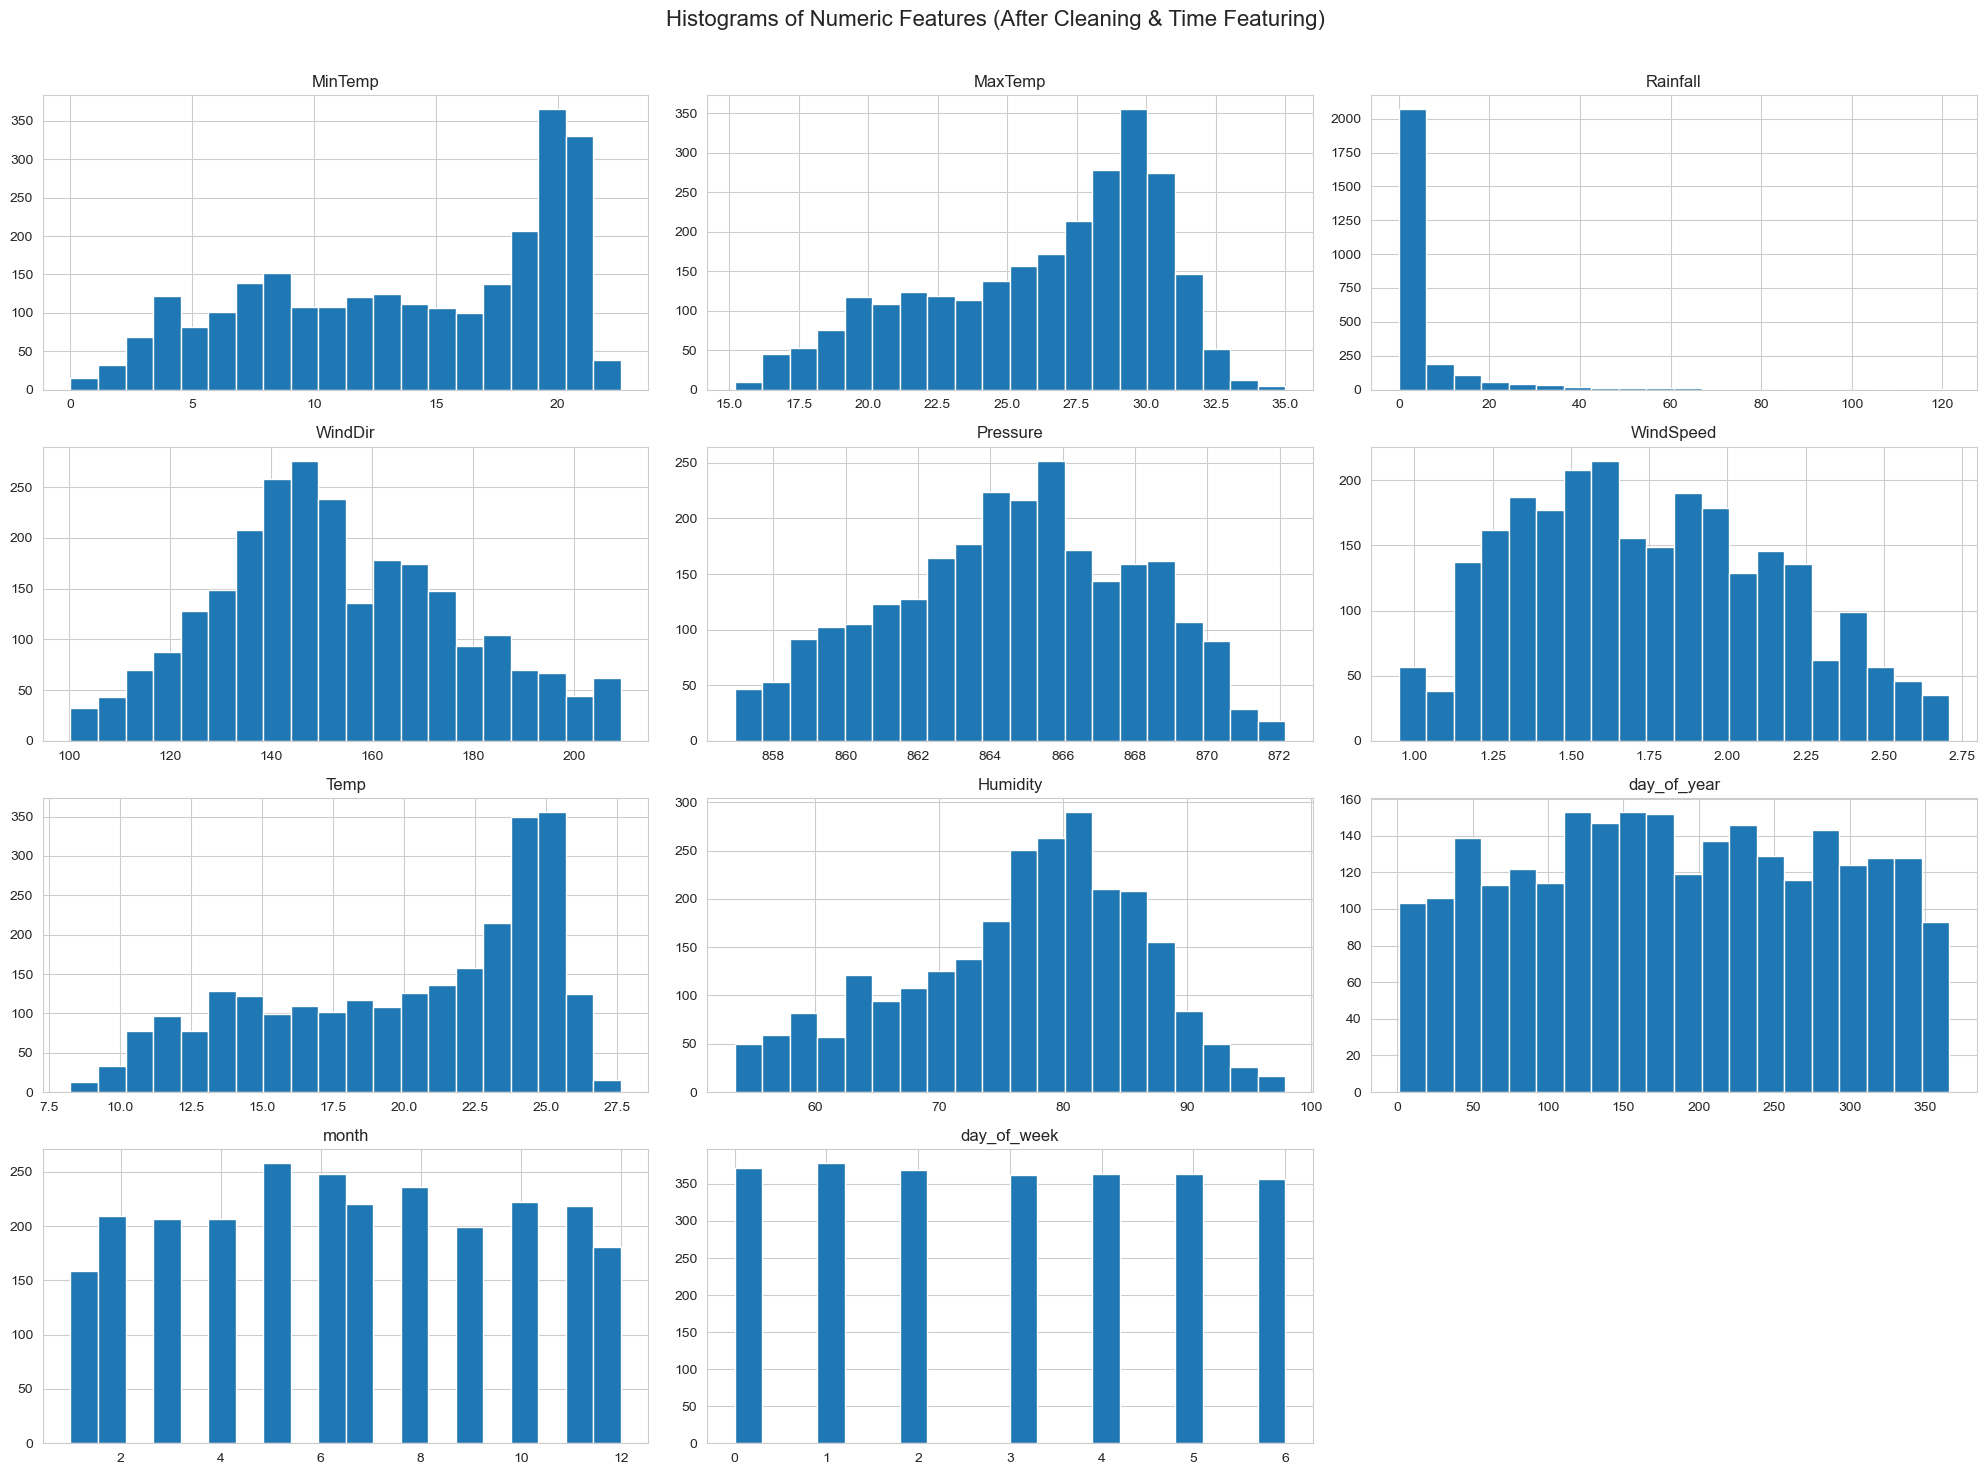

In [13]:
sns.set_style('whitegrid')
featured_df[FEATURES].hist(bins=20, figsize=(20, 15))
plt.suptitle('Histograms of Numeric Features (After Cleaning & Time Featuring)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()


**Custom Algorithm**

In [14]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
    def is_leaf_node(self):
        return self.value is not None

class DecisionTreeClassifier:
    def __init__(self, min_samples_split=2, max_depth=100, n_feats=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_feats = n_feats
        self.root = None
    def fit(self, X, y):
        self.n_feats = X.shape[1] if not self.n_feats else min(self.n_feats, X.shape[1])
        self.root = self._grow_tree(X, y)
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        if (depth >= self.max_depth or len(np.unique(y)) == 1 or n_samples < self.min_samples_split):
            return Node(value=self._most_common_label(y))
        feat_idxs = np.random.choice(n_features, self.n_feats, replace=False)
        best_feat, best_thresh = self._best_criteria(X, y, feat_idxs)
        if best_feat is None:
            return Node(value=self._most_common_label(y))
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)
    def _best_criteria(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None
        for feat_idx in feat_idxs:
            for threshold in np.unique(X[:, feat_idx]):
                gain = self._information_gain(y, X[:, feat_idx], threshold)
                if gain > best_gain:
                    best_gain, split_idx, split_thresh = gain, feat_idx, threshold
        return split_idx, split_thresh
    def _information_gain(self, y, X_column, split_thresh):
        parent_entropy = self._entropy(y)
        left_idxs, right_idxs = self._split(X_column, split_thresh)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        return parent_entropy - child_entropy
    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs
    def _entropy(self, y):
        hist = np.bincount(y.astype(int))
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
    def _most_common_label(self, y):
        return Counter(y).most_common(1)[0][0]
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class RandomForestClassifier:
    def __init__(self, n_trees=100, min_samples_split=2, max_depth=100, n_feats=None, random_state=None):
        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_feats = n_feats
        self.random_state = random_state
        self.trees = []
    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.trees = []
        for _ in range(self.n_trees):
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree = DecisionTreeClassifier(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                n_feats=self.n_feats
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    def _bootstrap_samples(self, X, y):
        idxs = np.random.choice(len(X), len(X), replace=True)
        return X[idxs], y[idxs]
    def _most_common_label(self, y):
        return Counter(y).most_common(1)[0][0]
    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees]).T
        return np.array([self._most_common_label(p) for p in preds])

class DecisionTreeRegressor:
    def __init__(self, min_samples_split=2, max_depth=100, n_feats=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_feats = n_feats
        self.root = None
    def fit(self, X, y):
        self.n_feats = X.shape[1] if not self.n_feats else min(self.n_feats, X.shape[1])
        self.root = self._grow_tree(X, y)
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        if (depth >= self.max_depth or n_samples < self.min_samples_split):
            return Node(value=np.mean(y))
        feat_idxs = np.random.choice(n_features, self.n_feats, replace=False)
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)
        if best_feat is None:
            return Node(value=np.mean(y))
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)
        
    def _best_split(self, X, y, feat_idxs):
        best_mse = float('inf')
        split_idx, split_thresh = None, None
        for feat_idx in feat_idxs:
            for threshold in np.unique(X[:, feat_idx]):
                left_idxs, right_idxs = self._split(X[:, feat_idx], threshold)
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue
                mse = (len(left_idxs) * np.var(y[left_idxs]) + len(right_idxs) * np.var(y[right_idxs])) / len(y)
                if mse < best_mse:
                    best_mse, split_idx, split_thresh = mse, feat_idx, threshold
        return split_idx, split_thresh
    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class RandomForestRegressor:
    def __init__(self, n_trees=100, min_samples_split=2, max_depth=100, n_feats=None, random_state=None):
        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_feats = n_feats
        self.random_state = random_state
        self.trees = []
    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.trees = []
        for _ in range(self.n_trees):
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree = DecisionTreeRegressor(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                n_feats=self.n_feats
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    def _bootstrap_samples(self, X, y):
        idxs = np.random.choice(len(X), len(X), replace=True)
        return X[idxs], y[idxs]
    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(preds, axis=0)

**Training and Saving trained models**

In [15]:
def prepare_data(df):
    TARGET_RAIN = 'RainToday'
    TARGET_TEMP = 'Temp'
    TARGET_HUMIDITY = 'Humidity'
    FEATURES_FOR_RAIN = [
        'MinTemp', 'MaxTemp', 'WindDir', 'Pressure',
        'WindSpeed', 'Temp', 'Humidity', 'day_of_year', 'month', 'day_of_week'
    ]
    FEATURES_FOR_TEMP = [
           'MinTemp', 'MaxTemp','Temp','Rainfall', 'WindDir', 'Pressure','WindSpeed', 
        'Humidity', 'day_of_year', 'month', 'day_of_week'
    ]  
    FEATURES_FOR_HUMIDITY = [
        'MinTemp', 'MaxTemp','Humidity', 'Rainfall', 
        'WindDir', 'Pressure', 'WindSpeed', 'Temp', 'day_of_year', 'month', 'day_of_week'
    ] 
    
    X_rain = df[FEATURES_FOR_RAIN].values
    y_rain = df[TARGET_RAIN].values
    X_temp = df[FEATURES_FOR_TEMP].values
    y_temp = df[TARGET_TEMP].values
    X_humidity = df[FEATURES_FOR_HUMIDITY].values
    y_humidity = df[TARGET_HUMIDITY].values
    
    return X_rain, y_rain, FEATURES_FOR_RAIN, X_temp, y_temp, FEATURES_FOR_TEMP, X_humidity, y_humidity, FEATURES_FOR_HUMIDITY

def train_and_save_models(df, save_path='.'):
    model_files = ['rain_model.joblib', 'temp_model.joblib', 'humidity_model.joblib', 'features.joblib']
  
    
    if all(os.path.exists(os.path.join(save_path, f)) for f in model_files):
        print("Loading existing models.")
        try:
            rain_model = joblib.load(os.path.join(save_path, 'rain_model.joblib'))
            temp_model = joblib.load(os.path.join(save_path, 'temp_model.joblib'))
            humidity_model = joblib.load(os.path.join(save_path, 'humidity_model.joblib'))
            loaded_features = joblib.load(os.path.join(save_path, 'features.joblib'))
            X_rain, y_rain, _, X_temp, y_temp, _, X_humidity, y_humidity, _ = prepare_data(df)
            train_size = int(len(X_rain) * 0.8)
            X_test_rain = X_rain[train_size:]
            y_test_rain = y_rain[train_size:]
            X_test_temp = X_temp[train_size:]
            y_test_temp = y_temp[train_size:]
            X_test_humidity = X_humidity[train_size:]
            y_test_humidity = y_humidity[train_size:]
            print("y_temp range:", y_temp.min(), y_temp.max())
            print("y_humidity range:", y_humidity.min(), y_humidity.max())
            results = {
                "rain_model": rain_model,
                "temp_model": temp_model,
                "humidity_model": humidity_model,
                "X_test_rain": X_test_rain,
                "y_test_rain": y_test_rain,
                "X_test_temp": X_test_temp,
                "y_test_temp": y_test_temp,
                "X_test_humidity": X_test_humidity,
                "y_test_humidity": y_test_humidity,
                "features": loaded_features
            }
            return "loaded", results
        except Exception as e:
            print(f"Error loading models: {e}")
            raise
    X_rain, y_rain, FEATURES_FOR_RAIN, X_temp, y_temp, FEATURES_FOR_TEMP, X_humidity, y_humidity, FEATURES_FOR_HUMIDITY = prepare_data(df)
    FEATURES_DICT = {
        'rain': FEATURES_FOR_RAIN,
        'temp': FEATURES_FOR_TEMP,
        'humidity': FEATURES_FOR_HUMIDITY
    }
    train_size = int(len(X_rain) * 0.8)
    X_train_rain, X_test_rain = X_rain[:train_size], X_rain[train_size:]
    y_train_rain, y_test_rain = y_rain[:train_size], y_rain[train_size:]
    X_train_temp, X_test_temp = X_temp[:train_size], X_temp[train_size:]
    y_train_temp, y_test_temp = y_temp[:train_size], y_temp[train_size:]  
    X_train_humidity, X_test_humidity = X_humidity[:train_size], X_humidity[train_size:]
    y_train_humidity, y_test_humidity = y_humidity[:train_size], y_humidity[train_size:]
    
    print("\nTraining Models")
    n_features_rain = X_train_rain.shape[1] 
    n_feats_sqrt_rain = int(np.sqrt(n_features_rain))
    rain_model = RandomForestClassifier(n_trees=50, max_depth=10,n_feats=n_feats_sqrt_rain, random_state=42)
    rain_model.fit(X_train_rain, y_train_rain)
    print("Rain model trained.")

    n_features_temp = X_train_temp.shape[1]
    n_feats_sqrt_temp = int(np.sqrt(n_features_temp))
    temp_model = RandomForestRegressor(n_trees=50, max_depth=10,n_feats=n_feats_sqrt_temp, random_state=42)
    temp_model.fit(X_train_temp, y_train_temp)
    print("Temperature model trained.")

    n_features_humidity = X_train_humidity.shape[1]
    n_feats_sqrt_humidity = int(np.sqrt(n_features_humidity))   
    humidity_model = RandomForestRegressor(n_trees=50, max_depth=10,n_feats=n_feats_sqrt_humidity, random_state=42)
    humidity_model.fit(X_train_humidity, y_train_humidity)
    print("Humidity model trained.")
    
    try:
        os.makedirs(save_path, exist_ok=True)
        joblib.dump(rain_model, os.path.join(save_path, 'rain_model.joblib'))
        joblib.dump(temp_model, os.path.join(save_path, 'temp_model.joblib'))
        joblib.dump(humidity_model, os.path.join(save_path, 'humidity_model.joblib'))
        joblib.dump(FEATURES_DICT, os.path.join(save_path, 'features.joblib'))
        print("\nAll models saved successfully.")
    except Exception as e:
        print(f"Error saving models: {e}")
        raise
    
    results = {
        "rain_model": rain_model,
        "temp_model": temp_model,
        "humidity_model": humidity_model,
        "X_test_rain": X_test_rain,
        "y_test_rain": y_test_rain,
        "X_test_temp": X_test_temp,
        "y_test_temp": y_test_temp,
        "X_test_humidity": X_test_humidity,
        "y_test_humidity": y_test_humidity,
        "features": FEATURES_DICT
    }
    return "trained", results

**Evaluating Models**

In [16]:
def evaluate_models(results):
    print("Model Evaluation on Unseen Test Data")
    rain_model = results["rain_model"]
    temp_model = results["temp_model"]
    humidity_model = results["humidity_model"]
    X_test_rain = results["X_test_rain"]
    y_test_rain = results["y_test_rain"]
    X_test_temp = results["X_test_temp"]
    y_test_temp = results["y_test_temp"]
    X_test_humidity = results["X_test_humidity"]
    y_test_humidity = results["y_test_humidity"]

    print("\nRain Model Evaluation")
    rain_preds = rain_model.predict(X_test_rain)
    print(f"Accuracy: {accuracy_score(y_test_rain, rain_preds):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test_rain, rain_preds, target_names=['No Rain', 'Rain']))

    print("\nTemperature Model Evaluation")
    temp_preds = temp_model.predict(X_test_temp)
    temp_mse = mean_squared_error(y_test_temp, temp_preds)
    temp_rmse = np.sqrt(temp_mse)
    temp_mae = mean_absolute_error(y_test_temp, temp_preds)
    print(f"Mean Absolute Error (MAE):   {temp_mae:.2f} °C")
    print(f"Root Mean Squared Error (RMSE): {temp_rmse:.2f}°C")

    print("\nHumidity Model Evaluation")
    humidity_preds = humidity_model.predict(X_test_humidity)
    humidity_mse = mean_squared_error(y_test_humidity, humidity_preds)
    humidity_rmse = np.sqrt(humidity_mse)
    humidity_mae = mean_absolute_error(y_test_humidity, humidity_preds)
    print(f"Mean Absolute Error (MAE):   {humidity_mae:.2f} %")
    print(f"Root Mean Squared Error (RMSE): {humidity_rmse:.2f}%")

try:
    df = pd.read_csv('weather.csv')
    featured_df = features(df_no_outliers)
    results = train_and_save_models(featured_df)
    status = results[0] if isinstance(results, tuple) else None
    results_dict = results[1] if isinstance(results, tuple) else results
    print(f"Models {'loaded' if status == 'loaded' else 'trained'} successfully.")
    evaluate_models(results_dict)
    print(f"Evaluation completed using {'loaded' if status == 'loaded' else 'trained'} models.")
except Exception as e:
    print(f"Failed to process data, train, or load models: {str(e)}")
    raise

Loading existing models.
y_temp range: 8.25 27.65
y_humidity range: 53.5 97.885
Models loaded successfully.
Model Evaluation on Unseen Test Data

Rain Model Evaluation
Accuracy: 83.04%

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.83      0.90      0.86       305
        Rain       0.84      0.72      0.78       208

    accuracy                           0.83       513
   macro avg       0.83      0.81      0.82       513
weighted avg       0.83      0.83      0.83       513


Temperature Model Evaluation
Mean Absolute Error (MAE):   0.13 °C
Root Mean Squared Error (RMSE): 0.20°C

Humidity Model Evaluation
Mean Absolute Error (MAE):   0.99 %
Root Mean Squared Error (RMSE): 1.44%
Evaluation completed using loaded models.


***Getting live weather data from API***

In [17]:
def get_current_weather(city, save_path='.'):
    url = f"{BASE_URL}weather?q={city}&appid={API_KEY}&units=metric"
    try:
        response = requests.get(url)
        data = response.json()
        if response.status_code != 200 or data.get('cod') == '404':
            print(f"API returned an error or city not found: {data.get('message','Status code was not 200')}")
            return None

        if data.get('cod') != 200:
             raise ValueError(f"API error: {data.get('message', 'Unknown error')}")

        utc_dt = datetime.fromtimestamp(data['dt'], tz=pytz.UTC)
        api_timestamp = utc_dt.strftime('%Y-%m-%d %H:%M:%S UTC')
        print(f"Raw data: {data}")
        print(f"API Data Timestamp: {api_timestamp}")
        weather_data = {
            'city': data['name'],
            'current_temp': float(data['main'].get('temp',0)),
            'feels_like': round(float(data['main'].get('feels_like',0))),
            'temp_min': round(float(data['main'].get('temp_min',0))),
            'temp_max': round(float(data['main'].get('temp_max',0))),
            'humidity': round(float(data['main'].get('humidity',0))),
            'description': data['weather'][0].get('description', 'unknown'),
            'country': data['sys'].get('country', 'Unknown'),
            'wind_dir': float(data['wind'].get('deg',0)),
            'wind_speed': float(data['wind'].get('speed',0)),
            'pressure': float(data['main'].get('pressure',0)),
            'rainfall':  data.get('rain', {}).get('1h', 0),
            'clouds': int(data['clouds'].get('all')),
            'visibility': int(data.get('visibility',0)),
            'timezone_offset': int(data.get('timezone', 0))
        }
        last_row = pd.DataFrame([{
            'Temp': weather_data['current_temp'],
            'MinTemp': weather_data['temp_min'],
            'MaxTemp': weather_data['temp_max'],
            'Humidity': weather_data['humidity'],
            'Pressure': weather_data['pressure'],
            'WindSpeed': weather_data['wind_speed'] * 3.6,
            'WindDir': weather_data['wind_dir'],
            'Rainfall': weather_data['rainfall'],
            'RainToday': None
        }])
        joblib.dump(last_row, f'{save_path}/last_day.joblib')
        print(f"Successfully fetched API Data for {city}.")
        return weather_data
    except (requests.RequestException, ValueError, KeyError) as e:
        print(f"API Request Failed for {city}: {e}. Using fallback data.")
        try:
            last_row = joblib.load('last_day.joblib').iloc[0]
            print("Using fallback data from the last day of the dataset.")
            return {
                'city': city,
                'current_temp': round(float(last_row['Temp'])),
                'feels_like': round(float(last_row['Temp'])),
                'temp_min': round(float(last_row['MinTemp'])),
                'temp_max': round(float(last_row['MaxTemp'])),
                'humidity': round(float(last_row['Humidity'])),
                'description': 'Data unavailable (fallback)',
                'country': 'Unknown',
                'wind_dir': float(last_row['WindDir']),
                'wind_speed': float(last_row['WindSpeed']),
                'pressure': float(last_row['Pressure']),
                'rainfall': float(last_row['Rainfall']),
                'clouds': 50,
                'visibility': 10000,
                'timezone_offset': 0
            }
        except Exception as fallback_e:
            print(f"Fallback data error: {fallback_e}")
            return None

In [18]:
def predict_future(model, current_features, features_list, start_time):
    target = 'Temp' if 'Temp' in current_features else 'Humidity'
    predictions = [current_features[target]]
    feature_data = current_features.copy()
    for i in range(5):
        future_time = start_time + timedelta(hours=i+1)
        feature_data['hour'] = future_time.hour
        feature_data['day_of_year'] = future_time.timetuple().tm_yday
        feature_data['month'] = future_time.month
        feature_data['day_of_week'] = future_time.weekday()
        prediction_df = pd.DataFrame([feature_data])[features_list].fillna(0)
        next_value = model.predict(prediction_df.values)[0]
        predictions.append(next_value)
        feature_data[target] = next_value
    return predictions[1:]

***Main Function***

In [19]:
try:
    rain_model = joblib.load('rain_model.joblib')
    loaded_features = joblib.load('features.joblib')
    temp_model = joblib.load('temp_model.joblib')
    humidity_model = joblib.load('humidity_model.joblib')
except FileNotFoundError:
    print("Error: Model files not found. Please run the training cell first.")
    rain_model, loaded_features, temp_model, humidity_model = [None] * 4

def weather_view(city=None):
    if not all([rain_model, loaded_features, temp_model, humidity_model]):
        print("Cannot run view; models are not loaded.")
        return
    if city is None:
        try:
            city = input("Enter City Name: ").strip()
        except EOFError:
            print("Error: City name must be provided.")
            return
    if not city:
        print("Error: City name cannot be empty.")
        return

    current_weather = get_current_weather(city)
    if current_weather is None:
        print("Couldnot find city name. Please enter valid city.")
        return

    tz_offset = timedelta(seconds=current_weather.get('timezone_offset', 0))
    city_timezone = pytz.FixedOffset(tz_offset.total_seconds() / 60)
    now = datetime.now(city_timezone)
    next_hour = now.replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)
    future_times = [(next_hour + timedelta(hours=i)).strftime("%H:00") for i in range(5)]
    current_features = {
        'MinTemp': current_weather['temp_min'],
        'MaxTemp': current_weather['temp_max'],
        'Rainfall': current_weather.get('rainfall', 0),
        'WindDir': current_weather['wind_dir'],
        'Pressure': current_weather['pressure'],
        'WindSpeed': current_weather['wind_speed'] * 3.6,
        'Temp': current_weather['current_temp'],
        'Humidity': current_weather['humidity'],
        'day_of_year': now.timetuple().tm_yday,
        'month': now.month,
        'day_of_week': now.weekday()
    }

    try:
        rain_features = loaded_features.get('rain', [])
        temp_features = loaded_features.get('temp', [])
        humidity_features = loaded_features.get('humidity', [])
        if not all([rain_features, temp_features, humidity_features]):
            raise ValueError("One or more feature lists in features_loaded are empty or missing")

        current_df_rain = pd.DataFrame([current_features])[rain_features].fillna(0)
        rain_prediction = rain_model.predict(current_df_rain.values)[0]
        future_temp_preds = predict_future(temp_model, current_features, temp_features, start_time=now)
        future_humidity_preds = predict_future(humidity_model, current_features, humidity_features, start_time=now)

        print(f"\nCity: {current_weather['city']}, {current_weather['country']}")
        print(f"Date: {now.strftime('%Y-%m-%d')}, Time: {now.strftime('%H:%M %p')}")
        print(f"Description: {current_weather['description'].capitalize()}")
        print(f"Current Temperature: {current_weather['current_temp']}°C")
        print(f"Feels Like: {current_weather['feels_like']}°C")
        print(f"Humidity: {current_weather['humidity']}%")
        print(f"Wind: {current_weather['wind_speed']:.1f} m/s from {current_weather['wind_dir']}°")
        print(f"Pressure: {current_weather['pressure']} hPa")
        print(f"Prediction for Rain: "
              f"{'A chance of rain' if rain_prediction == 1 else 'No chance of rain'}")
        print("\nFuture Forecast (next 5 hours):")
        print("Time  |Temp (°C) | Humidity (%)")
        print("------|----------|-------------")
        for i in range(5):
            print(f"{future_times[i]:<3} | " f"{round(future_temp_preds[i], 1):<8} | "
                  f"{round(future_humidity_preds[i], 1):<12}")

    except Exception as e:
        print("Error during prediction:", str(e))


np.random.seed(42)
weather_view()

Enter City Name:  Melbourne


Raw data: {'coord': {'lon': -80.6081, 'lat': 28.0836}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 24.35, 'feels_like': 25.11, 'temp_min': 24.35, 'temp_max': 24.35, 'pressure': 1017, 'humidity': 87, 'sea_level': 1017, 'grnd_level': 1017}, 'visibility': 10000, 'wind': {'speed': 2.33, 'deg': 233, 'gust': 2.56}, 'clouds': {'all': 88}, 'dt': 1752139230, 'sys': {'country': 'US', 'sunrise': 1752143591, 'sunset': 1752193324}, 'timezone': -14400, 'id': 4163971, 'name': 'Melbourne', 'cod': 200}
API Data Timestamp: 2025-07-10 09:20:30 UTC
Successfully fetched API Data for Melbourne.

City: Melbourne, US
Date: 2025-07-10, Time: 05:20 AM
Description: Overcast clouds
Current Temperature: 24.35°C
Feels Like: 25°C
Humidity: 87%
Wind: 2.3 m/s from 233.0°
Pressure: 1017.0 hPa
Prediction for Rain: A chance of rain

Future Forecast (next 5 hours):
Time  |Temp (°C) | Humidity (%)
------|----------|-------------
06:00 | 2